# Strategic Import Analysis: Growth and Risk
A Global Economic Study of Import Footprints and Supply Chain Stability

In global trade, sheer volume can be misleading. To provide actionable value for business leaders, this notebook moves beyond basic metrics to identify where the hidden growth opportunities are and how volatile those markets are for long-term investment.

### Key Objectives:
1. **Historical Data Forensics:** Prove that "missing data" in global economics is actually a timeline of geopolitical events (e.g., the collapse of the USSR).
2. **The Monopoly Baseline:** Quantify the exact market share controlled by the Top 10 global powers.
3. **Identify Emerging Markets (CAGR):** Discover the "Hidden Gems" by calculating 10-year Compound Annual Growth Rates.
4. **Risk vs. Reward Matrix:** Map the volatility of these high-growth markets to build a stable supply chain investment strategy.


In [1]:
# Basic Libs
import numpy as np 
import pandas as pd 

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")


In [2]:
# File Path
path = "/kaggle/input/datasets/mdmahfuzsumon/from-ports-to-profits-global-import-dataset/world_bank_Import_Usd_enriched.csv"

# Loading Dataset 
df = pd.read_csv(path)

# Data Preprocessing

In [3]:
print(df.columns.tolist())

['Country', 'Year', ' Imports_Current_USD ', 'Continent', 'Subregion', 'Income_Group', 'Development_Status', 'Geo_Cluster']


In [4]:
# Drops the Space in Columns 
df.columns = df.columns.str.strip()

In [5]:
# Checking Size of the Dataset
df.shape

(11067, 8)

In [6]:
# Checking for Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11067 entries, 0 to 11066
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Country              11067 non-null  object
 1   Year                 11067 non-null  int64 
 2   Imports_Current_USD  7763 non-null   object
 3   Continent            11067 non-null  object
 4   Subregion            11067 non-null  object
 5   Income_Group         11067 non-null  object
 6   Development_Status   11067 non-null  object
 7   Geo_Cluster          11067 non-null  object
dtypes: int64(1), object(7)
memory usage: 691.8+ KB


In [7]:
# To Find the Range of the timeline
df.describe()

,Year
count,11067.000000
mean,1999.000000
std,14.720267
min,1974.000000
25%,1986.000000
50%,1999.000000
75%,2012.000000
max,2024.000000


In [8]:
df.head()

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster
0,Afghanistan,2024,NaN,Asia,South Asia,Low income,Developing,Asia_Low income
1,Afghanistan,2023,"8,701,650,584.05",Asia,South Asia,Low income,Developing,Asia_Low income
2,Afghanistan,2022,"7,901,784,705.75",Asia,South Asia,Low income,Developing,Asia_Low income
3,Afghanistan,2021,"5,286,118,076.13",Asia,South Asia,Low income,Developing,Asia_Low income
4,Afghanistan,2020,"7,241,822,542.18",Asia,South Asia,Low income,Developing,Asia_Low income


In [9]:
# Checking for Unique Values
df.nunique()

Country                 217
Year                     51
Imports_Current_USD    7758
Continent                 6
Subregion                24
Income_Group              4
Development_Status        2
Geo_Cluster              21
dtype: int64

In [10]:
# Checking for Nulls
df.isnull().sum()

Country                   0
Year                      0
Imports_Current_USD    3304
Continent                 0
Subregion                 0
Income_Group              0
Development_Status        0
Geo_Cluster               0
dtype: int64

In [11]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
# Categorizes by year and country
df = df.sort_values(by=['Country', 'Year'])

In [13]:
# Converting Dtype to Numerical
df["Imports_USD"] = pd.to_numeric(
    df["Imports_Current_USD"].astype(str).str.replace(",", "", regex=False).str.strip(), 
    errors='coerce'
)

In [14]:
df= df.drop(columns=['Imports_Current_USD'])

In [15]:
# Seperating the Nulls
missing_data = df[df['Imports_USD'].isnull()]

# Counts the missing values by Income and Country 
nulls_by_income = missing_data['Income_Group'].value_counts()
nulls_by_country = missing_data['Country'].value_counts()

print("Missing Rows by Income Group:")
print(nulls_by_income)

print("Missing Rows by Countries:")
print(nulls_by_country)


Missing Rows by Income Group:
Income_Group
High income            1373
Upper middle income     859
Lower middle income     592
Low income              480
Name: count, dtype: int64
Missing Rows by Countries:
Country
Barbados                     51
Andorra                      51
Sint Maarten (Dutch part)    51
St. Kitts and Nevis          51
British Virgin Islands       51
                             ..
Cyprus                        1
Kiribati                      1
Kuwait                        1
Oman                          1
Zimbabwe                      1
Name: count, Length: 130, dtype: int64


# EDA

## Geopolitical Timeline

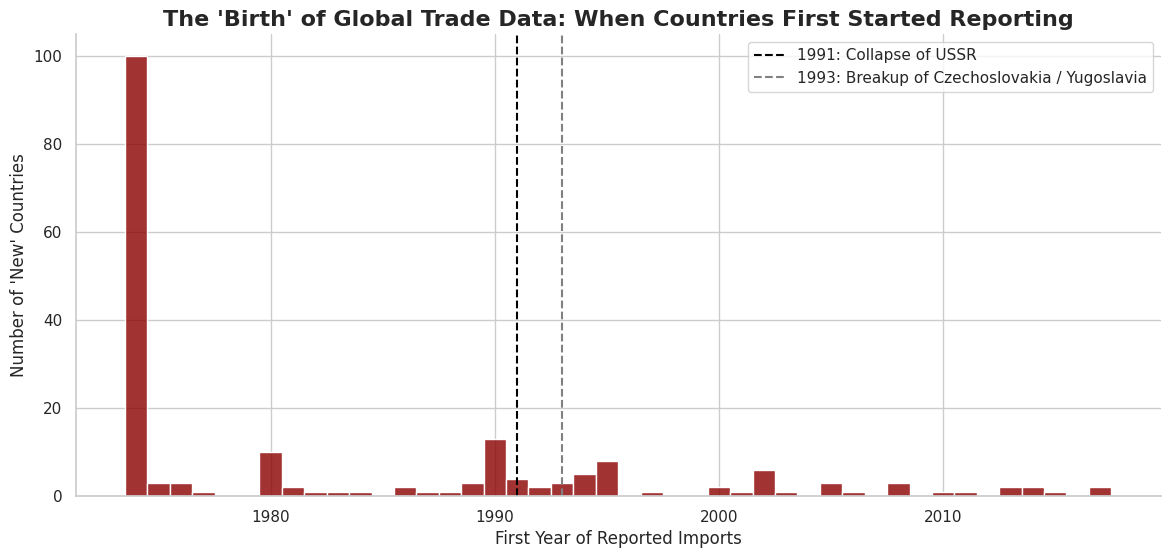

In [16]:
plt.figure(figsize=(14, 6))

# Finds the "First Entry Year" of data for each country
first_reporting_year = df.dropna(subset=['Imports_USD']).groupby('Country')['Year'].min().reset_index()
first_reporting_year.rename(columns={'Year': 'First_Year'}, inplace=True)

# Histogram
ax = sns.histplot(
    data=first_reporting_year, 
    x="First_Year", 
    discrete=True,
    color="darkred",
    alpha=0.8
)

# Real life Events
plt.axvline(x=1991, color='black', linestyle='--', label='1991: Collapse of USSR')
plt.axvline(x=1993, color='gray', linestyle='--', label='1993: Breakup of Czechoslovakia / Yugoslavia')

plt.title("The 'Birth' of Global Trade Data: When Countries First Started Reporting", fontsize=16, fontweight='bold')
plt.xlabel("First Year of Reported Imports", fontsize=12)
plt.ylabel("Number of 'New' Countries", fontsize=12)
plt.legend()
sns.despine()

plt.show()

### Observation

* The missing data is a historical feature rather than a mistake.
* These gaps show when certain countries did not exist, such as those formed after the collapse of the USSR, or were economically isolated.

## Volume Monopoly

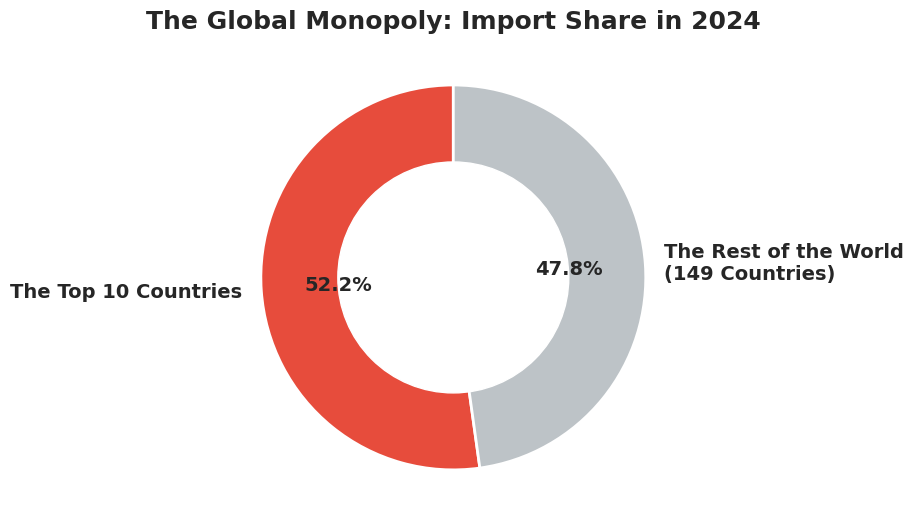

In [17]:
# Gets data for the most recent year
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year].dropna(subset=['Imports_USD'])

# Calculates the "Monopoly"
total_global_imports = df_latest['Imports_USD'].sum()
top_10_sum = df_latest.nlargest(10, 'Imports_USD')['Imports_USD'].sum()
rest_of_world_sum = total_global_imports - top_10_sum

# Donut Chart
labels = ['The Top 10 Countries', f'The Rest of the World\n({len(df_latest) - 10} Countries)']
sizes = [top_10_sum, rest_of_world_sum]
colors = ['#e74c3c', '#bdc3c7']

plt.figure(figsize=(9, 9))

# Pie
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(f"The Global Monopoly: Import Share in {latest_year}", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation

* The top ten countries hold a larger share of the import market than the rest of the world combined.
* This concentration shows that a small group of nations remains the primary anchor for global trade volume.

## Regional Growth Leaders: CAGR Analysis (2013-2023)

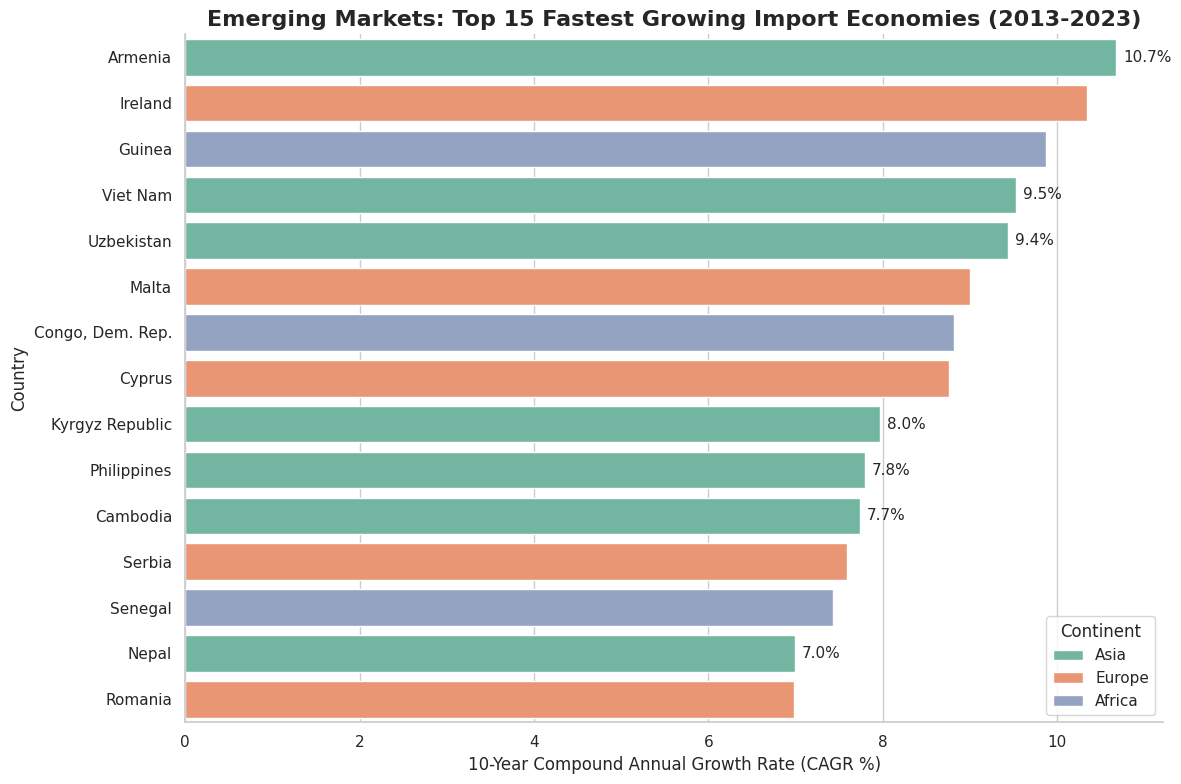

In [18]:
# 10-year span (2013 vs 2023)
start_year, end_year = 2013, 2023
df_cagr = df[df['Year'].isin([start_year, end_year])].pivot(
    index=['Country', 'Continent'], 
    columns='Year', 
    values='Imports_USD'
).reset_index().dropna()

# Filters for significant markets (Must have at least $10 Billion in imports in 2023)
df_cagr = df_cagr[df_cagr[end_year] > 10_000_000_000]

# Calculates 10-Year CAGR Formula
df_cagr['CAGR_%'] = ((df_cagr[end_year] / df_cagr[start_year]) ** (1/10) - 1) * 100

# Top 15 Fastest Growing Markets
top_cagr = df_cagr.nlargest(15, 'CAGR_%')

# Plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_cagr, 
    x='CAGR_%', 
    y='Country', 
    hue='Continent', 
    dodge=False,
    palette='Set2'
)

# data labels
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5, fontsize=11)

plt.title(f"Emerging Markets: Top 15 Fastest Growing Import Economies ({start_year}-{end_year})", fontsize=16, fontweight='bold')
plt.xlabel("10-Year Compound Annual Growth Rate (CAGR %)", fontsize=12)
plt.ylabel("Country", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

### Observation

* Regional leaders emerge when looking at the fastest-growing import economies over a ten-year span.
* Armenia, Vietnam, and Uzbekistan lead growth in Asia.
* Ireland, Malta, and Cyprus are the leaders in Europe.
* Guinea, Congo, and Senegal lead the growth trends in Africa.

## Supply Chain Risk vs. Reward

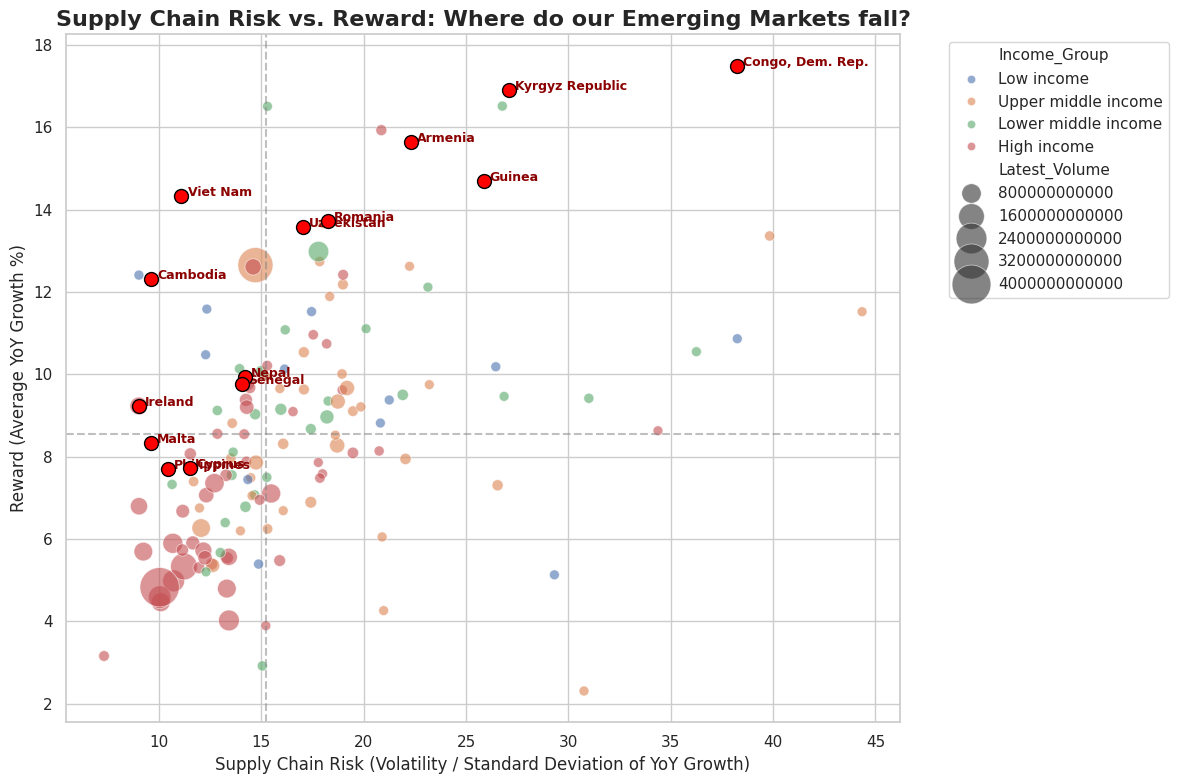

In [19]:
# Filter for modern trade era (Post-2000) to get relevant business data
df_risk = df[df['Year'] >= 2000].copy()

# Calculates YoY Growth percentage
df_risk['YoY_Growth_%'] = df_risk.groupby('Country')['Imports_USD'].pct_change(fill_method=None) * 100

# Aggregates Average Growth (Reward) and Standard Deviation (Risk/Volatility)
risk_matrix = df_risk.groupby(['Country', 'Continent', 'Income_Group']).agg(
    Avg_Growth=('YoY_Growth_%', 'mean'),
    Volatility=('YoY_Growth_%', 'std'),
    Latest_Volume=('Imports_USD', 'last')
).reset_index().dropna()

# Filters out extreme outliers and micro-economies to make the chart readable
risk_matrix = risk_matrix[
    (risk_matrix['Latest_Volume'] > 5_000_000_000) & # > $5 Billion
    (risk_matrix['Avg_Growth'] < 40) &               # Removes data anomalies
    (risk_matrix['Volatility'] < 60)
]

# Plotting the Risk vs. Reward Matrix
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=risk_matrix, 
    x='Volatility', 
    y='Avg_Growth', 
    hue='Income_Group',
    size='Latest_Volume', 
    sizes=(50, 800), 
    alpha=0.6,
    palette='deep'
)

# Crosshairs to divide the grid into 4 Business Quadrants
avg_volatility = risk_matrix['Volatility'].median()
avg_growth = risk_matrix['Avg_Growth'].median()
plt.axvline(avg_volatility, color='gray', linestyle='--', alpha=0.5)
plt.axhline(avg_growth, color='gray', linestyle='--', alpha=0.5)

# BRIDGE TO CASE 1: HIGHLIGHT EMERGING MARKETS 
emerging_market_names = top_cagr['Country'].tolist()

for idx, row in risk_matrix.iterrows():
    if row['Country'] in emerging_market_names:
        plt.text(row['Volatility'] + 0.3, row['Avg_Growth'], row['Country'], 
                 fontsize=9, fontweight='bold', color='darkred')
        plt.scatter(row['Volatility'], row['Avg_Growth'], color='red', edgecolor='black', s=100, zorder=5)

plt.title("Supply Chain Risk vs. Reward: Where do our Emerging Markets fall?", fontsize=16, fontweight='bold')
plt.xlabel("Supply Chain Risk (Volatility / Standard Deviation of YoY Growth)", fontsize=12)
plt.ylabel("Reward (Average YoY Growth %)", fontsize=12)

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observation

* Most of the top fifteen emerging markets fall into a stable zone, with growth rates and risk scores between ten and twenty.
* Congo, the Kyrgyz Republic, and Guinea are major outliers with risk scores between twenty-five and thirty-six.
* Congo shows the highest supply chain risk overall in this group.

## Shift in Global Market Share

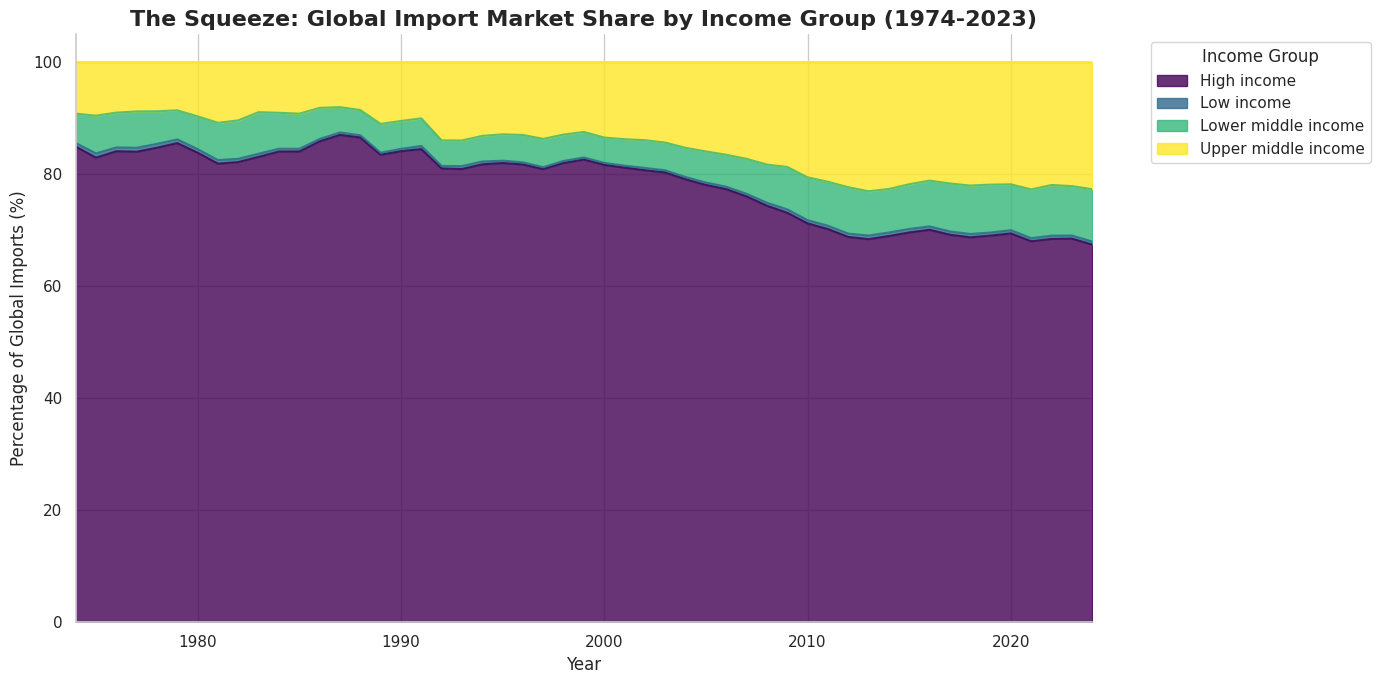

In [20]:
# Groups data by Year and Income Group
income_trend = df.dropna(subset=['Imports_USD']).groupby(['Year', 'Income_Group'])['Imports_USD'].sum().unstack()

# Converts raw dollars to 100% Market Share (Percentages)
income_percentage = income_trend.div(income_trend.sum(axis=1), axis=0) * 100

# Plot a 100% Stacked Area Chart
plt.figure(figsize=(14, 7))
income_percentage.plot(kind='area', stacked=True, alpha=0.8, colormap='viridis', ax=plt.gca())

# Formatting
plt.title("The Squeeze: Global Import Market Share by Income Group (1974-2023)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage of Global Imports (%)", fontsize=12)
plt.legend(title="Income Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(x=0, y=0)
sns.despine()
plt.tight_layout()
plt.show()

### Observation

* High-income nations saw their market share drop from roughly 82% to 70% over the studied period.

* Upper-middle-income countries were the primary gainers, increasing their share from 10% to 22%.

* Lower-middle-income shares grew to 8%, while low-income shares remained stagnant at approximately 1%.

# Conclusion

This study analyzed global import markets to provide a stable framework for business strategy. We identified three strategic imperatives:

* **Gaps Tell the Story**: Data gaps are historical footprints of geopolitical shifts rather than simple errors.

* **Identify New Frontiers**: While the top ten economies dominate volume, their growth is stagnating; the real momentum is in emerging markets with high ten-year growth rates.

* **Balance Risk and Reward**: High growth must be balanced against volatility. Businesses should prioritize emerging markets in the low-volatility, high-growth quadrant to ensure supply chain stability.

**Final Thought**: The future belongs to agile leaders who can move beyond the current monopoly and navigate high-growth, stable frontiers.